In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [8]:
#sample data
data = {
    'Age': [25, 30, 35, 40, 45],
    'Salary': [50000, 60000, 80000, 110000, 150000],
    'Experience': [1, 3, 5, 7, 10],
    'Loan': [0, 0, 1, 1, 1]
}
df = pd.DataFrame(data)

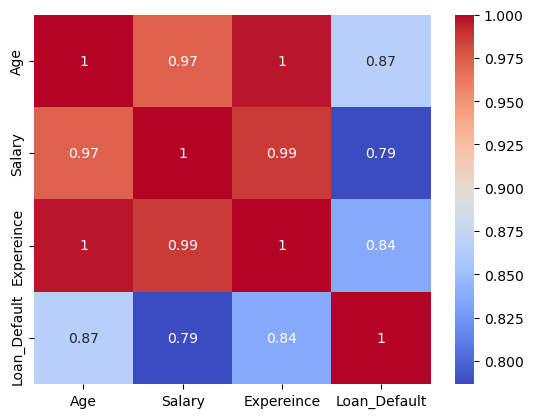

In [3]:
#corelation matrix
corr_matrix = df.corr()
#plot correlation heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [4]:
from sklearn.feature_selection import chi2
from sklearn.feature_selection import SelectKBest

In [9]:
x = df[['Age', 'Salary', 'Experience']]
y = df[['Loan']]

In [12]:
#Apply chi-square test
chi_scores, p_values = chi2(x,y)

In [13]:
for i, col in enumerate(x.columns):
    print(f"Feature: {col}, chi2 Score: {chi_scores[i]}, p_values: {p_values[i]}")

Feature: Age, chi2 Score: 5.357142857142858, p_values: 0.020637558243972117
Feature: Salary, chi2 Score: 45370.37037037037, p_values: 0.0
Feature: Experience, chi2 Score: 6.564102564102566, p_values: 0.010405619868873575


In [14]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier


In [15]:
#sample data
x= df[['Age', 'Salary', 'Experience']]
y= df['Loan']

In [16]:
#use RFE
model= RandomForestClassifier()
rfe= RFE(model, n_features_to_select=2)
rfe.fit(x,y)

,estimator,RandomForestClassifier()
,n_features_to_select,2
,step,1
,verbose,0
,importance_getter,'auto'
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [17]:
#output selected features
print("Selected features:", x.columns[rfe.support_])

Selected features: Index(['Salary', 'Experience'], dtype='object')


In [18]:
from sklearn.linear_model import Lasso

In [20]:
#sample data
x= df[['Age', 'Salary', 'Experience']]
y= df['Loan']

In [21]:
#apply lasso regression
lasso= Lasso(alpha=0.1)
lasso.fit(x,y)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [24]:
#output
lasso_coef = pd.Series(lasso.coef_, index=x.columns)
print("Feature importance using Lasso:\n", lasso_coef)

Feature importance using Lasso:
 Age           0.093545
Salary       -0.000007
Experience    0.000000
dtype: float64


In [25]:
from sklearn.ensemble import RandomForestClassifier

In [26]:
#train random forest
rf= RandomForestClassifier()
rf.fit(x,y)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Feature Importance using Random Forest:
 Age           0.244681
Salary        0.414894
Experience    0.340426
dtype: float64


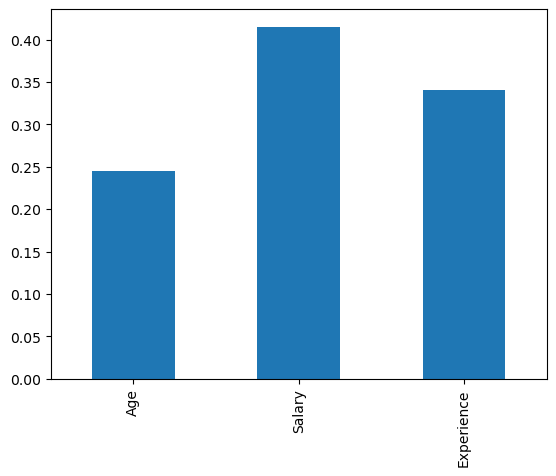

In [28]:
#output from feature importance
importances = pd.Series(rf.feature_importances_, index=x.columns)
print("Feature Importance using Random Forest:\n", importances)
importances.plot(kind= 'bar')
plt.show()                 

In [34]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [35]:
#create a sample data set
data = {'Height': [65, 67, 70, 68,72],
        'Weight': [150, 160, 200, 180, 210]
       }
df = pd.DataFrame(data)

In [36]:
#standardise the data
scaler= StandardScaler()
scaled_data = scaler.fit_transform(df)

In [38]:
#apply pca
pca= PCA(n_components=2)
principal_components = pca.fit_transform(scaled_data)

In [39]:
#results
explained_variance_ratio = pca.explained_variance_ratio_
print("Explained Variance Ratio:",explained_variance_ratio)

Explained Variance Ratio: [0.98995441 0.01004559]
